# LCA Product Retrieval — Find the Right Product from Any Search

**Author:** Jay Parmar 
---

### 🔧 How it works 

```
user query → intent extraction → routed retrieval (exact / BM25 / BM25+Dense+RRF) → constraint re-rank → top-k
```

| Component | Library | What it handles |
|---|---|---|
| BM25 | `rank_bm25` | Exact tokens — EPD IDs, grade codes, spec values |
| Dense embeddings | `sentence-transformers` (`bge-small-en-v1.5`) | Semantic similarity — synonyms, vague queries |
| Fusion | Reciprocal Rank Fusion (RRF) | Combines BM25 + Dense without score normalisation |
| Constraint re-rank | pure Python | Verifies hard rules (16mm, 1770 MPa, A1 fire class) against parsed fields |

### 📖 How to read this notebook
The pipeline is: 
**1 Data → 2 Preprocessing → 3 Retrieval Engine → 4 Example Searches → 5 Evaluation → 6 Limitations & Roadmap**. 

Run cells top-to-bottom; the first run downloads one small model (~130 MB) and caches everything, so later runs are fully offline and fast.


In [89]:
import subprocess, sys

# Install the two non-standard libraries we need.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "rank_bm25", "sentence-transformers", "-q"],
    check=False
)


[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: pip3.10 install --upgrade pip


CompletedProcess(args=['/usr/local/bin/python3.10', '-m', 'pip', 'install', 'rank_bm25', 'sentence-transformers', '-q'], returncode=0)

In [90]:
import os, re, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional
from difflib import get_close_matches  # for fuzzy typo correction
from rank_bm25 import BM25Okapi

plt.rcParams.update({"figure.figsize": (12, 4), "font.size": 10})

# CONFIG — all tunable parameters in ONE place.
#
# To change any setting, edit here.  You can also load from an external file:
#   CONFIG = json.load(open("config.json"))
_DEFAULTS = {
    # File paths and model
    "data_path":   "synthetic_products_200 2.csv",
    "embed_cache": "embeddings.npy",           # cached so we don't re-encode every run
    "embed_model": "BAAI/bge-small-en-v1.5",  # top-ranked small model on BEIR benchmark
    "top_k":       5,                           # how many results to return
    "rrf_k":       60,                          # RRF constant (larger = less aggressive re-ranking)

    # SKU prefix → product category mapping.
    # Each SKU code starts with a prefix that identifies the product type.
    # e.g. CEM-1001 → Cement, SCB-0042 → Steel Cables
    "sku_category": {
        "CEM": "Cement",    "SCB": "Steel Cables", "INS": "Insulation",
        "BLK": "Concrete Blocks", "PNT": "Paint",   "PLB": "Plasterboard",
        "TMB": "Timber",   "RBR": "Rebar",          "WPF": "Waterproofing",
        "PIP": "Pipes"
    },

    # Keywords that indicate each product category in a user query.
    # Keep this list small — the fuzzy matcher catches typos automatically.
    # Example: "cmt" is listed explicitly (too short for fuzzy matching);
    #          "cment" is NOT listed — difflib finds it automatically.
    "category_synonyms": {
        "Cement":          ["cement", "cem ", "portland", "concrete mix", "mortar", "cmt"],
        "Steel Cables":    ["steel cable", "wire rope", "cable", "strand", "liftline"],
        "Insulation":      ["insulation", "insulating", "thermal", "rock wool", "mineral wool",
                            "pir board", "stone wool", "thermapanel"],
        "Concrete Blocks": ["block", "concrete block", "aac", "aircrete"],
        "Paint":           ["paint", "coating", "primer", "facade coat"],
        "Plasterboard":    ["plasterboard", "gypsum board", "drywall", "fireboard"],
        "Timber":          ["timber", "wood", "beam", "glulam", "clt", "lvl", "spruce"],
        "Rebar":           ["rebar", "reinforcing bar", "ribbed bar", "b500", "deformed bar"],
        "Waterproofing":   ["waterproof", "membrane", "bitumen", "roof seal"],
        "Pipes":           ["pipe", "sewer", "drain", "hdpe", "upvc", "pprc"]
    }
}

# Load external config if present, otherwise use the defaults above
CONFIG = json.load(open("rag_config.json")) if os.path.exists("rag_config.json") else _DEFAULTS
print(f"Config loaded  |  top_k={CONFIG['top_k']}  |  model={CONFIG['embed_model']}")

Config loaded  |  top_k=5  |  model=BAAI/bge-small-en-v1.5


## 1 — The Data

The cell below (a) classifies each row into one of 5 formats using delimiter/prefix heuristics, (b) probes the raw text with regexes to measure which structured fields (EPD ID, SKU, dimensions, strength, certifications) are present and how often, and (c) plots both. The format label drives the format-specific parsers in Section 2; the coverage scan tells us which fields we can rely on downstream.

200 products  |  columns: ['product_id', 'raw_text']


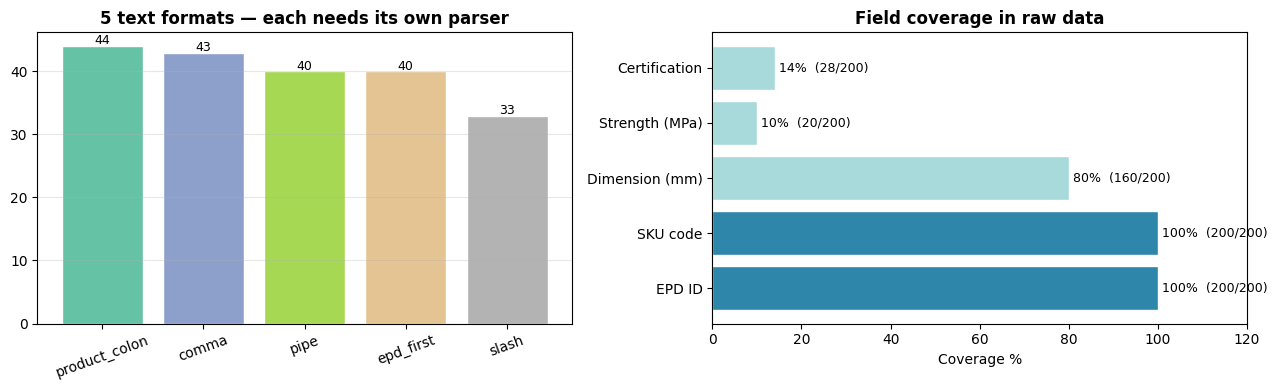


One example per format:
  [comma         ]  Heidelberg Materials Portland Max, C30/37, 25kg, declaration EPD202400001, sku CEM-1001, optimized for high du...
  [pipe          ]  Premium Mix Plus | manufacturer Heidelberg Materials | product code CEM-1002 | EPD202400002 | C25/30 | 25kg | ...
  [slash         ]  Rapid Set Eco by Holcim / cement / CEM I 42.5N / 25kg / CEM-1003 / environmental declaration EPD202400003 / in...
  [epd_first     ]  EPD202400004 Buzzi Unicem Rapid Set Standard C30/37 25kg optimized for high durability and fast installation c...
  [product_colon ]  Product: Rapid Set Ultra; Maker: CEMEX; Specs: C30/37; 25kg; ID: EPD202400010; Ref: CEM-1010; intended for int...


In [91]:
df = pd.read_csv(CONFIG["data_path"])
print(f"{len(df)} products  |  columns: {list(df.columns)}")

def _detect_format(text: str) -> str:
    if text.startswith("Product:"):      return "product_colon"
    if re.match(r"^EPD\d{9}", text):    return "epd_first"
    if " | " in text:                    return "pipe"
    if " / " in text:                    return "slash"
    return "comma"

df["fmt"] = df["raw_text"].apply(_detect_format)

coverage = {
    "EPD ID":          df["raw_text"].apply(lambda t: bool(re.search(r"EPD\d{9}",             t, re.I))).sum(),
    "SKU code":        df["raw_text"].apply(lambda t: bool(re.search(r"\b[A-Z]{2,5}-\d{4}\b", t))).sum(),
    "Dimension (mm)": df["raw_text"].apply(lambda t: bool(re.search(r"\d+\s*mm",              t, re.I))).sum(),
    "Strength (MPa)": df["raw_text"].apply(lambda t: bool(re.search(r"\d+\s*MPa",             t))).sum(),
    "Certification":  df["raw_text"].apply(lambda t: bool(re.search(r"PEFC|FSC|A1 fire",      t, re.I))).sum(),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

vc   = df["fmt"].value_counts()
bars = ax1.bar(vc.index, vc.values, color=plt.cm.Set2(np.linspace(0, 1, len(vc))), edgecolor="white")
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, str(int(b.get_height())), ha="center", fontsize=9)
ax1.set_title("5 text formats — each needs its own parser", fontweight="bold")
ax1.tick_params(axis="x", rotation=20); ax1.yaxis.grid(True, alpha=0.3)

hb = ax2.barh(list(coverage.keys()), [v / 200 * 100 for v in coverage.values()],
              color=["#2E86AB" if v == 200 else "#A8DADC" for v in coverage.values()], edgecolor="white")
for bar, v in zip(hb, coverage.values()):
    ax2.text(v/200*100+1, bar.get_y()+bar.get_height()/2, f"{v/200*100:.0f}%  ({v}/200)", va="center", fontsize=9)
ax2.set_xlim(0, 120); ax2.set_xlabel("Coverage %")
ax2.set_title("Field coverage in raw data", fontweight="bold")
plt.tight_layout(); plt.show()

print("\nOne example per format:")
for fmt in df["fmt"].unique():
    sample = df[df["fmt"] == fmt]["raw_text"].iloc[0]
    print(f"  [{fmt:14s}]  {sample[:110]}{'...' if len(sample) > 110 else ''}")

## 2 — Preprocessing: from messy text to structured fields

Each `raw_text` string is parsed into a typed `ProductRecord` in three steps:

1. **Regex** — extract universal fields (EPD ID, SKU, dimensions, weights, strengths, grades, certifications) that appear consistently across all formats.
2. **Format-specific parsers** — extract manufacturer and product name, whose position depends on the detected format; manufacturers are bootstrapped from the corpus itself (3-pass, see code).
3. **Normalization** — rebuild a clean, delimiter-free string from the extracted fields. This is what BM25 and the embedding model actually index, so the five raw layouts all look identical to the retrievers.

In [92]:
# Regex patterns — compiled once, reused for every product and every query.
#
# Two groups:
#   Product-time: strict patterns that match exactly within product descriptions.
#   Query-time:   permissive patterns that tolerate surrounding text in a query.

# Product-time patterns (strict)
EPD_RE    = re.compile(r"EPD\d{9}",                    re.I)   # e.g. EPD202400001
SKU_RE    = re.compile(r"\b([A-Z]{2,5})-(\d{4})\b")            # e.g. CEM-1001  (group 1=prefix, group 2=number)
MM_RE     = re.compile(r"(\d+(?:\.\d+)?)\s*mm",        re.I)   # e.g. 12.5mm
KG_RE     = re.compile(r"(\d+)\s*kg\b",                re.I)   # e.g. 25kg
LITRE_RE  = re.compile(r"(\d+)\s*L\b")                         # e.g. 5L
MPA_RE    = re.compile(r"(\d+)\s*MPa")                         # e.g. 1770 MPa
LAMBDA_RE = re.compile(r"lambda\s*([\d.]+)",           re.I)   # e.g. lambda 0.035
GRADE_RE  = re.compile(                                         # concrete grade, cement class, rebar grade...
    r"C\d+/\d+"                  # e.g. C30/37
    r"|CEM\s+[IVX]+(?:/[A-Z]-[A-Z])?\s+[\d.]+[NR]?"  # e.g. CEM II/B-V 32.5N
    r"|B500[BC]?"                # e.g. B500B
    r"|PN\d+|SN\d+"              # e.g. PN16, SN8
    r"|GL\d+[hc]|T\d+\.\d+"     # e.g. GL24h
)
CERT_RE   = re.compile(r"PEFC|FSC|A1\s*fire\s*class|CE\s*mark", re.I)
COLOR_RE  = re.compile(r"\b(black|white|grey|gray|blue|red|green|beige|cream|RAL\s*\d+)\b", re.I)
USE_RE    = re.compile(                                          # intended use description
    r"(optimized for.*|suitable for.*|intended for.*"
    r"|designed for.*|engineered for.*|commonly used.*)", re.I
)

# Query-time patterns — more permissive so they work inside a full sentence
# Example: "give me details on EPD202400001" → EPD_Q_RE still finds the ID
EPD_Q_RE  = re.compile(r"\bEPD\d{6,}\b",          re.I)
SKU_Q_RE  = re.compile(r"\b[A-Z]{2,5}-\d{3,4}\b")
SPEC_Q_RE = re.compile(                                          # spec values in a query
    r"\d+\s*mm|\d+\s*MPa|\d+\s*kg|C\d+/\d+|B500[BC]?|PN\d+|lambda\s*[\d.]+", re.I
)


@dataclass
class ProductRecord:
    """
    One product, parsed from raw_text into individual typed fields.
    All fields are optional except product_id and raw_text.
    """
    product_id:      str
    raw_text:        str
    # Identifiers
    epd_id:          Optional[str]   = None
    sku:             Optional[str]   = None
    category:        Optional[str]   = None
    # Who / what
    manufacturer:    Optional[str]   = None
    product_name:    Optional[str]   = None
    # Physical specs
    dimensions_mm:   list            = field(default_factory=list)
    weight_kg:       Optional[float] = None
    volume_l:        Optional[float] = None
    strength_mpa:    Optional[float] = None
    lambda_value:    Optional[float] = None
    grade:           Optional[str]   = None
    color:           Optional[str]   = None
    # Other attributes
    certifications:  list            = field(default_factory=list)
    use_description: Optional[str]   = None
    # Cleaned text used for indexing
    normalized_text: str             = ""

    def specs_str(self) -> str:
        """Return all numeric specs as a compact readable string."""
        parts = []
        if self.dimensions_mm: parts.extend(f"{d}mm" for d in self.dimensions_mm)
        if self.weight_kg:     parts.append(f"{self.weight_kg}kg")
        if self.volume_l:      parts.append(f"{self.volume_l}L")
        if self.strength_mpa:  parts.append(f"{self.strength_mpa}MPa")
        if self.lambda_value:  parts.append(f"\u03bb={self.lambda_value}")
        if self.grade:         parts.append(self.grade)
        return " | ".join(parts)

In [ ]:
# Manufacturer extraction

def bootstrap_manufacturers(df: pd.DataFrame) -> list:
    """
    Discover manufacturer names from raw text — no hardcoded list needed.
    Returns names sorted longest-first
    """
    found = {}  # {manufacturer_name: count}

    # --- Pass 1: high-confidence explicit patterns ---
    # Pattern A: "Maker: Heidelberg Materials" or "manufacturer Sika"
    pat_maker = re.compile(
        r"(?:Maker|manufacturer)\s*[:\s]+([A-Z][A-Za-z\s\-&.]+?)(?:\s*[|;,/]|$)", re.M)
    # Pattern B: "ProductName by Manufacturer /"  (slash-delimited format)
    pat_by    = re.compile(
        r"\bby\s+([A-Z][A-Za-z\s\-&.]{3,35}?)(?:\s*/)", re.M)

    for text in df["raw_text"]:
        for pattern in (pat_maker, pat_by):
            match = pattern.search(text)
            if match:
                name = match.group(1).strip()
                found[name] = found.get(name, 0) + 1
                break

    # Pattern C: pipe format — "ProductName | Manufacturer | ..."
    # The second "|"-delimited segment is always the manufacturer in pipe format.
    for text in df["raw_text"]:
        if " | " not in text or text.startswith("Product:"):
            continue  # not pipe format
        segs = text.split(" | ")
        if len(segs) < 2:
            continue
        candidate = segs[1].strip()
        # Valid manufacturer: starts with capital, only letters/spaces/hyphens/dots, no digits
        if re.match(r"^[A-Z][A-Za-z\s\-&.]{2,40}$", candidate):
            found[candidate] = found.get(candidate, 0) + 1

    # --- Pass 2: scan products not yet covered ---
    # Use pass-1 names to find manufacturers in epd_first and comma formats
    # where there is no explicit keyword or pipe delimiter.
    known_names = sorted(found, key=len, reverse=True)  # longest-first is critical

    for text in df["raw_text"]:
        # Skip if a known manufacturer already appears in this text
        already_covered = any(name.lower() in text.lower() for name in known_names)
        if already_covered:
            continue

        # Try each known name as a word-boundary match (prevents partial matches)
        for name in known_names:
            pattern = r"\b" + re.escape(name) + r"\b"
            if re.search(pattern, text, re.I):
                found[name] = found.get(name, 0) + 1
                break

    # --- Pass 3: recover names that never appear with an explicit marker ---
    # Some manufacturers (e.g. "Metsa Wood", "Uponor") only ever occur at the
    # very START of comma / epd_first texts, so passes 1-2 never see them.
    # Heuristic: a leading word (or word pair) that starts SEVERAL still-uncovered
    # products is a manufacturer name, not a product name.
    names_so_far = sorted(found, key=len, reverse=True)
    uncovered = []
    for text in df["raw_text"]:
        if any(re.search(r"\b" + re.escape(n) + r"\b", text, re.I) for n in names_so_far):
            continue  # already explained by a known manufacturer
        lead = re.sub(r"^EPD\d+\s+", "", text)        # drop leading EPD id (epd_first format)
        uncovered.append(lead.replace(",", " ").split())

    # Count 2-word prefixes first ("Metsa Wood"), then 1-word ("Uponor", "Knauf").
    # A prefix repeated >= 2 times across uncovered products is accepted.
    for n_words in (2, 1):
        prefix_counts = {}
        for words in uncovered:
            prefix = " ".join(words[:n_words])
            prefix_counts[prefix] = prefix_counts.get(prefix, 0) + 1
        for prefix, count in prefix_counts.items():
            if count >= 2 and prefix not in found and re.match(r"^[A-Z][A-Za-z\s\-&.]+$", prefix):
                found[prefix] = count
        # Drop products now covered before counting shorter prefixes
        uncovered = [w for w in uncovered
                     if not any(" ".join(w[:k]) in found for k in (2, 1))]

    # Sort longest-first so "Knauf Insulation" is always checked before "Knauf"
    return sorted(found, key=len, reverse=True)



def _extract_manufacturer(text: str, known_manufacturers: list) -> Optional[str]:
    """
    Find the manufacturer name in a single product text.
    Three strategies tried in priority order.
    """
    # Priority 1: explicit keyword — e.g. "Maker: Sika"
    match = re.search(
        r"(?:Maker|manufacturer)\s*[:\s]+([A-Z][A-Za-z\s\-&.]+?)(?:\s*[|;,/]|$)", text)
    if match:
        return match.group(1).strip()

    # Priority 2: "by X" attribution — e.g. "EcoBatt by Knauf Insulation /"
    match = re.search(r"\bby\s+([A-Z][A-Za-z\s\-&.]{3,35}?)(?:\s*/|$)", text)
    if match:
        candidate = match.group(1).strip()
        # Validate against known list to reject false positives like "by Design"
        for mfr in known_manufacturers:
            if mfr.lower() == candidate.lower():
                return mfr

    # Priority 3: substring scan — longest name first to avoid prefix collision
    for mfr in known_manufacturers:
        if mfr.lower() in text.lower():
            return mfr

    return None


def _extract_product_name(text: str, manufacturer: Optional[str], fmt: str) -> Optional[str]:
    """
    Extract the product name — logic differs per format because each format
    puts the name in a different position.
    """
    if fmt == "product_colon":
        # Format: "Product: EcoBatt 100mm; Maker: Knauf..."
        match = re.search(r"Product:\s*([^;]+)", text)
        return match.group(1).strip() if match else None

    if fmt == "pipe":
        # Format: "EcoBatt 100mm | Knauf Insulation | ..."
        # Product name is always the first segment
        return text.split(" | ")[0].strip()

    if fmt == "slash":
        # Format: "EcoBatt 100mm by Knauf Insulation / CEM-1001 / ..."
        first_segment = text.split(" / ")[0].strip()
        # Remove the manufacturer suffix if present ("EcoBatt 100mm by Knauf")
        match = re.match(r"^(.*?)\s+by\s+", first_segment, re.I)
        if match:
            return match.group(1).strip()
        # If first segment IS the manufacturer, there's no product name here
        if manufacturer and first_segment.lower() == manufacturer.lower():
            return None
        return first_segment

    if fmt == "epd_first":
        # Format: "EPD202400001 Knauf EcoBatt 100mm Rock Wool ..."
        # Skip the leading EPD token, then remove the manufacturer name
        tokens    = text.split()
        remaining = " ".join(tokens[1:])  # drop "EPD202400001"
        if manufacturer:
            remaining = re.sub(re.escape(manufacturer), "", remaining, flags=re.I).strip()
        # Product name ends when we hit a spec code
        match = re.match(r"^([A-Za-z\s]+?)(?:\s+C\d|B500|\d+mm|\d+kg|\d+L|\s+code)", remaining)
        return match.group(1).strip() if match else remaining.split("  ")[0].strip()

    # Default: comma format — "Heidelberg Materials Portland Max, C30/37, 25kg, ..."
    first_segment = text.split(",")[0].strip()
    # If segment starts with the manufacturer, the product name follows it
    if manufacturer and first_segment.startswith(manufacturer):
        product_name = first_segment[len(manufacturer):].strip()
        return product_name or None
    return first_segment

In [94]:
def parse_record(product_id: str, raw_text: str,
                known_mfrs: list, sku_category: dict) -> ProductRecord:
    """
    Parse one raw_text string into a fully structured ProductRecord.

    Steps:
      1. Detect format
      2. Extract universal fields via regex (same across all formats)
      3. Extract format-dependent fields (manufacturer, product name)
      4. Build normalized_text — the clean string BM25 and embeddings will index
    """
    record = ProductRecord(product_id=product_id, raw_text=raw_text)
    fmt    = _detect_format(raw_text)

    match = EPD_RE.search(raw_text)
    if match:
        record.epd_id = match.group(0).upper()  # normalize to uppercase: epd202400001 → EPD202400001

    match = SKU_RE.search(raw_text)
    if match:
        record.sku      = match.group(0)               # full SKU, e.g. CEM-1001
        prefix          = match.group(1)                # prefix only, e.g. CEM
        record.category = sku_category.get(prefix)     # CEM → Cement

    # MM_RE can match multiple values (e.g. "100mm x 600mm"), so use findall
    record.dimensions_mm = [float(x) for x in MM_RE.findall(raw_text)]

    match = KG_RE.search(raw_text)
    if match: record.weight_kg   = float(match.group(1))

    match = LITRE_RE.search(raw_text)
    if match: record.volume_l    = float(match.group(1))

    match = MPA_RE.search(raw_text)
    if match: record.strength_mpa = float(match.group(1))

    match = LAMBDA_RE.search(raw_text)
    if match: record.lambda_value = float(match.group(1))

    match = GRADE_RE.search(raw_text)
    if match: record.grade = match.group(0).strip()

    match = COLOR_RE.search(raw_text)
    if match: record.color = match.group(0).strip()

    match = USE_RE.search(raw_text)
    if match: record.use_description = match.group(0).strip()

    # CERT_RE can match multiple certifications (PEFC AND FSC in same product)
    record.certifications = CERT_RE.findall(raw_text)

    record.manufacturer = _extract_manufacturer(raw_text, known_mfrs)
    record.product_name = _extract_product_name(raw_text, record.manufacturer, fmt)

    # Combine all extracted fields into one clean string.
    # This removes format-specific delimiters (|, /, commas) and makes every
    # product look the same to BM25 and the embedding model.
    parts = [v for v in [record.category, record.manufacturer, record.product_name, record.grade] if v]
    if record.specs_str():      parts.append(record.specs_str())
    if record.color:            parts.append(record.color)
    if record.certifications:   parts.append(" ".join(record.certifications))
    if record.use_description:  parts.append(record.use_description)
    if record.epd_id:           parts.append(record.epd_id)  # include IDs so BM25 can match them exactly
    if record.sku:              parts.append(record.sku)
    record.normalized_text = " ".join(parts)

    return record

In [95]:

# Bootstrap manufacturers from the data — no hardcoded list
MANUFACTURERS = bootstrap_manufacturers(df)
print(f"Bootstrapped {len(MANUFACTURERS)} manufacturers from raw data")
print(f"  Top 8: {', '.join(MANUFACTURERS[:8])}")

# Parse every product into a typed ProductRecord
records    = [
    parse_record(row.product_id, row.raw_text, MANUFACTURERS, CONFIG["sku_category"])
    for _, row in df.iterrows()
]
pid_to_rec = {r.product_id: r for r in records}  # fast lookup by product ID

cov = {
    "EPD ID":           sum(1 for r in records if r.epd_id),
    "SKU":              sum(1 for r in records if r.sku),
    "Category":         sum(1 for r in records if r.category),
    "Manufacturer":     sum(1 for r in records if r.manufacturer),
    "Product Name":     sum(1 for r in records if r.product_name),
    "Dimensions (mm)": sum(1 for r in records if r.dimensions_mm),
    "Grade / Standard": sum(1 for r in records if r.grade),
    "Certification":    sum(1 for r in records if r.certifications),
}
cov_df = pd.DataFrame(
    [(field, count, f"{count/200*100:.0f}%") for field, count in cov.items()],
    columns=["Field", "Extracted", "Coverage"]
)
print("\nExtraction Coverage (200 products):")
print(cov_df.to_string(index=False))

# Show one before → after example for 3 representative formats
print("\nBefore / After normalization:")
for target_fmt in ("comma", "slash", "epd_first"):
    r = next(r for r in records if _detect_format(r.raw_text) == target_fmt)
    print(f"\n  [{target_fmt}]")
    print(f"    RAW : {r.raw_text[:100]}...")
    print(f"    NORM: {r.normalized_text[:100]}...")

Bootstrapped 49 manufacturers from raw data
  Top 8: GCP Applied Technologies, Heidelberg Materials, Saint-Gobain Gyproc, Knauf Insulation, Bridon-Bekaert, ArcelorMittal, Georg Fischer, Titan Cement

Extraction Coverage (200 products):
           Field  Extracted Coverage
          EPD ID        200     100%
             SKU        200     100%
        Category        200     100%
    Manufacturer        200     100%
    Product Name        200     100%
 Dimensions (mm)        160      80%
Grade / Standard         67      34%
   Certification         28      14%

Before / After normalization:

  [comma]
    RAW : Heidelberg Materials Portland Max, C30/37, 25kg, declaration EPD202400001, sku CEM-1001, optimized f...
    NORM: Cement Heidelberg Materials Portland Max C30/37 25.0kg | C30/37 optimized for high durability and fa...

  [slash]
    RAW : Rapid Set Eco by Holcim / cement / CEM I 42.5N / 25kg / CEM-1003 / environmental declaration EPD2024...
    NORM: Cement Holcim Rapid Set Ec

## 3 — The Retrieval Engine

Three retrieval strategies, fused and then constraint-re-ranked:

| Strategy | When it wins | When it fails |
|---|---|---|
| **BM25** (`k1=1.5, b=0.75`) | Exact tokens — EPD IDs, grades (`C30/37`), spec values | Synonyms, paraphrases |
| **Dense** (`bge-small-en-v1.5`) | Semantic intent, synonyms, vague queries | Exact ID / spec matching |
| **Hybrid (RRF)** | Best of both — rank fusion, no score normalisation needed | Numeric AND-constraints |
| **Constraint re-rank** | Hard spec rules verified on parsed fields | Needs parsable specs |

RRF formula: &nbsp; `score(d) = 1/(k + rank_bm25) + 1/(k + rank_dense)` &nbsp; with `k=60`.

Query routing sends each query to the cheapest strategy that handles it correctly:

| Detected intent | Route | Reason |
|---|---|---|
| EPD / SKU in query | `exact` | Direct lookup — no ranking needed |
| Category only | `bm25_only` | BM25 on the category name is sufficient and fast |
| Multi-attribute or semantic | `hybrid` | Both models together give the best recall |

When the query states hard requirements (sizes, strengths, certifications, manufacturer), the retriever fetches a **larger candidate pool** (≥40) and stable-sorts it by *number of rules satisfied* — a re-rank rather than a hard filter, so the user still gets results when no product satisfies everything.

In [96]:
# Tokenizer + Index

def tokenize(text: str) -> list:
    """
    Split text into tokens while keeping compound codes intact.
    Standard split() would break 'EPD202400001', 'CEM-1001', 'C30/37', 'B500B'.
    This pattern keeps alphanumeric runs joined by / . -
    """
    return re.findall(r"[a-z0-9]+(?:[/.\-][a-z0-9]+)*", text.lower())


class ProductIndex:
    """
    Holds both the BM25 index and the dense embedding matrix.
    BM25 is built immediately; embeddings are loaded or built on demand.
    """
    def __init__(self, records: list, sku_category: dict):
        self.records      = records
        self.sku_category = sku_category
        # Build BM25 over normalized texts — k1 and b are standard Okapi BM25 parameters
        corpus       = [tokenize(r.normalized_text) for r in records]
        self.bm25    = BM25Okapi(corpus, k1=1.5, b=0.75)
        # Dense embeddings populated by load_or_build_dense()
        self.embeddings = None
        self.model      = None

    def load_or_build_dense(self, model_name: str, cache_path: str) -> None:
        """Load embeddings from disk cache, or encode all products and save."""
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer(model_name)

        if os.path.exists(cache_path):
            # Cache exists — load in milliseconds instead of re-encoding
            self.embeddings = np.load(cache_path)
            print(f"Dense index loaded from cache  (shape={self.embeddings.shape})")
        else:
            # First run — encode all 200 products (~60s on CPU)
            print("Building dense index — first run only (~60s on CPU)...")
            texts           = [r.normalized_text for r in self.records]
            self.embeddings = self.model.encode(
                texts, batch_size=32, normalize_embeddings=True, show_progress_bar=True
            )
            np.save(cache_path, self.embeddings)
            print(f"Embeddings saved to '{cache_path}' — future runs will load from cache")

In [97]:
# Query Intent Analysis
#
# Before retrieving anything, we parse the query to understand:
#   - Does it contain an exact product ID? → fast direct lookup
#   - What category is the user asking about?
#   - Is there a manufacturer name or spec value?
#
# This determines which retrieval strategy to use (routing).

def _build_fuzzy_vocab(config: dict) -> dict:
    """
    Build a flat word → category dictionary from category_synonyms.
    Used by difflib for fuzzy typo matching.
    Only includes single words ≥4 characters (shorter words are too ambiguous).
    """
    vocab = {}
    for category, synonyms in config["category_synonyms"].items():
        vocab[category.lower()] = category  # add the category name itself
        for synonym in synonyms:
            word = synonym.strip()
            if len(word) >= 4 and " " not in word:  # single word, long enough to match safely
                vocab[word] = category
    return vocab


def _query_constraints(query: str, intent: dict) -> list:
    """
    Turn every hard requirement found in the query into a checkable rule.

    Example: "steel cables 16mm 1770 MPa" produces two rules:
        16mm     -> is 16.0 in record.dimensions_mm?
        1770MPa  -> is record.strength_mpa == 1770?

    Returns a list of (label, predicate) pairs.  Each predicate takes a
    ProductRecord and answers True/False against the PARSED fields — so a
    product is only ranked first if it really satisfies the requirement,
    not because the number merely appears somewhere in its text.
    """
    cons = []

    # Numeric specs — dimensions can repeat ("60x200mm"), the rest are single
    for v in MM_RE.findall(query):
        cons.append((f"{v}mm", lambda r, v=float(v): v in r.dimensions_mm))
    m = KG_RE.search(query)
    if m:
        cons.append((f"{m.group(1)}kg", lambda r, v=float(m.group(1)): r.weight_kg == v))
    m = LITRE_RE.search(query)
    if m:
        cons.append((f"{m.group(1)}L", lambda r, v=float(m.group(1)): r.volume_l == v))
    m = MPA_RE.search(query)
    if m:
        cons.append((f"{m.group(1)}MPa", lambda r, v=float(m.group(1)): r.strength_mpa == v))
    m = LAMBDA_RE.search(query)
    if m:
        cons.append((f"lambda {m.group(1)}", lambda r, v=float(m.group(1)): r.lambda_value == v))
    elif "lambda" in query.lower():
        # Bare "lambda" with no value: user wants products with a declared lambda
        cons.append(("has lambda", lambda r: r.lambda_value is not None))

    # Grade / certification / colour
    m = GRADE_RE.search(query)
    if m:
        cons.append((m.group(0), lambda r, g=m.group(0): bool(r.grade) and g in r.grade))
    for c in CERT_RE.findall(query):
        cons.append((c, lambda r, c=c.lower(): any(c in x.lower() for x in r.certifications)))
    m = COLOR_RE.search(query)
    if m:
        cons.append((m.group(0), lambda r, c=m.group(0).lower(): bool(r.color) and c in r.color.lower()))

    # Manufacturer (substring match handles sub-brands: "Knauf" ~ "Knauf Insulation")
    if intent.get("detected_manufacturer"):
        mfr = intent["detected_manufacturer"]
        cons.append((mfr, lambda r, m=mfr.lower(): m in (r.manufacturer or "").lower()))

    return cons


def analyze_query(query: str, config: dict) -> dict:
    """
    Parse a user query and decide how to retrieve results.

    Returns a dict with:
      type                 — query category (exact_epd, category_vague, spec_filtered, ...)
      routing              — retrieval strategy (exact, bm25_only, hybrid)
      detected_category    — product category if found in query
      detected_manufacturer— manufacturer if found in query
      detected_specs       — list of spec strings found (dimensions, grades, weights)
      corrected_to         — set when a spelling correction was applied
      normalized_query     — query with typo replaced (used as actual retrieval query)
    """
    q_lower = query.lower()  # work on lowercase for all comparisons

    intent = {
        "type": None, "routing": None,
        "detected_category": None, "detected_manufacturer": None,
        "detected_specs": [], "corrected_to": None, "normalized_query": query,
    }

    # This short-circuits everything else — we know exactly which product.
    # EPD_Q_RE.search works on the full query string, so it handles:
    #   "EPD202400001"                      → plain ID
    #   "give me details on EPD202400001"   → ID inside a sentence
    if EPD_Q_RE.search(query):
        intent["type"]    = "exact_epd"
        intent["routing"] = "exact"
        return intent

    if SKU_Q_RE.search(query):
        intent["type"]    = "exact_sku"
        intent["routing"] = "exact"
        return intent

    # Check synonyms longest-first so "steel cable" matches before "cable".
    sorted_categories = sorted(
        config["category_synonyms"].items(),
        key=lambda kv: max(len(s) for s in kv[1]),  # sort by longest synonym
        reverse=True
    )
    for category, synonyms in sorted_categories:
        if any(syn in q_lower for syn in synonyms):
            intent["detected_category"] = category
            break  # stop at first match

    if not intent["detected_category"]:
        fuzzy_vocab = _build_fuzzy_vocab(config)
        for word in q_lower.split():
            # Skip short words (too risky) and words already in vocabulary
            if len(word) < 4 or word in fuzzy_vocab:
                continue
            close = get_close_matches(word, list(fuzzy_vocab.keys()), n=1, cutoff=0.80)
            if close:
                best_match = close[0]
                intent["detected_category"]   = fuzzy_vocab[best_match]
                intent["corrected_to"]         = f'"{word}" \u2192 "{best_match}" ({intent["detected_category"]})'
                intent["normalized_query"]     = q_lower.replace(word, best_match, 1)
                break

    # Check longest names first to avoid "Knauf" matching inside "Knauf Insulation".
    for mfr in sorted(MANUFACTURERS, key=len, reverse=True):
        if mfr.lower() in q_lower:
            intent["detected_manufacturer"] = mfr
            break

    intent["detected_specs"] = SPEC_Q_RE.findall(query)

    has_category     = bool(intent["detected_category"])
    has_manufacturer = bool(intent["detected_manufacturer"])
    has_specs        = bool(intent["detected_specs"])

    if has_category and not has_manufacturer and not has_specs:
        # Simple browse — BM25 alone is fast and sufficient
        intent["type"]    = "category_vague"
        intent["routing"] = "bm25_only"

    elif has_category and (has_manufacturer or has_specs):
        # Multi-attribute — needs semantic (dense) + exact token (BM25) together
        intent["type"]    = "spec_filtered" if has_specs else "manufacturer_filtered"
        intent["routing"] = "hybrid"

    else:
        # General / semantic query — use the full hybrid pipeline
        intent["type"]    = "general"
        intent["routing"] = "hybrid"

    # Every spec / certification / manufacturer mentioned in the query becomes
    # a (label, predicate) rule checked against parsed product fields.
    intent["constraints"] = _query_constraints(intent["normalized_query"], intent)

    return intent

In [ ]:
# ProductRetriever — three search methods + a routing layer

class ProductRetriever:
    def __init__(self, index: ProductIndex):
        self.index = index

    def _exact_lookup(self, query: str) -> Optional[ProductRecord]:
        """
        Find a product by its EPD ID or SKU — O(n) scan.
        Extracts just the ID from a natural-language query first:
          "give me details on EPD202400001" → search for "EPD202400001"
        """
        # Extract the ID pattern — ignore any surrounding words
        epd_match = EPD_Q_RE.search(query)
        sku_match  = SKU_Q_RE.search(query)

        if epd_match:
            key = epd_match.group(0).upper()
        elif sku_match:
            key = sku_match.group(0).upper()
        else:
            key = query.strip().upper()

        # Scan all records for a match
        for record in self.index.records:
            if record.epd_id and record.epd_id.upper() == key:
                return record
            if record.sku and record.sku.upper() == key:
                return record
        return None

    def bm25_search(self, query: str, top_k: int) -> list:
        """Keyword search — good for exact tokens (EPD IDs, grades, spec codes)."""
        scores = self.index.bm25.get_scores(tokenize(query))
        ranked = np.argsort(scores)[::-1][:top_k]  # sort descending, take top-k
        return [(self.index.records[i].product_id, float(scores[i])) for i in ranked]

    def dense_search(self, query: str, top_k: int) -> list:
        """Semantic search — good for synonyms, paraphrases, vague queries."""
        # Encode the query to the same vector space as the product embeddings
        query_vec = self.index.model.encode([query], normalize_embeddings=True)[0]
        # Cosine similarity = dot product when both vectors are L2-normalized
        scores    = self.index.embeddings @ query_vec
        ranked    = np.argsort(scores)[::-1][:top_k]
        return [(self.index.records[i].product_id, float(scores[i])) for i in ranked]

    def hybrid_search(self, query: str, top_k: int) -> list:
        """
        Combine BM25 and dense results using Reciprocal Rank Fusion.
        RRF score = 1/(k + rank_bm25) + 1/(k + rank_dense)
        where k=60 is a smoothing constant that reduces the weight of top-ranked items.
        Advantage: no need to normalise BM25 scores (integers) and dense scores (0-1 floats).
        """
        k   = 60
        rrf = {}  # product_id → accumulated RRF score

        # Add BM25 contribution
        for rank, (pid, _) in enumerate(self.bm25_search(query,  top_k * 3), start=1):
            rrf[pid] = rrf.get(pid, 0) + 1 / (k + rank)

        # Add dense contribution
        for rank, (pid, _) in enumerate(self.dense_search(query, top_k * 3), start=1):
            rrf[pid] = rrf.get(pid, 0) + 1 / (k + rank)

        # Sort by combined RRF score descending
        ranked = sorted(rrf.items(), key=lambda x: x[1], reverse=True)
        return ranked[:top_k]

    def retrieve(self, query: str, top_k: int, intent: dict, mode: str = "auto") -> list:
        """
        Route the query to the right search method based on detected intent.
        Returns [(product_id, score), ...] sorted best-first.
        """
        has_dense = self.index.embeddings is not None

        # --- Exact match ---
        # Use ID extracted from query (handles natural-language wrappers)
        if mode == "auto" and intent["routing"] == "exact":
            record = self._exact_lookup(query)
            if record:
                return [(record.product_id, 1.0)]  # score 1.0 = perfect match

        # --- Choose the retrieval query text ---
        # For category-browse queries: use the category name ("Cement") instead of
        # the raw query ("cmt" or "cment") so BM25 scores are meaningful.
        if intent["routing"] == "bm25_only":
            q = intent["detected_category"] or intent.get("normalized_query", query)
        else:
            q = intent.get("normalized_query", query)  # use corrected query if a typo was fixed

        # --- Hard constraints from the query (specs, certs, manufacturer) ---
        # Only applied in 'auto' mode, so the pure bm25/dense evaluation modes
        # stay untouched and the mode comparison in Section 5 remains honest.
        constraints = (intent.get("constraints") or []) if mode == "auto" else []
        # With constraints we fetch a LARGER candidate pool: the right product
        # may sit at rank 20 on raw text similarity, and the re-rank below
        # can only promote products that made it into the pool.
        pool = max(top_k * 6, 40) if constraints else top_k * 3

        # --- Run the chosen search strategy ---
        if mode == "auto" and intent["routing"] == "bm25_only":
            results = self.bm25_search(q, pool)
        elif mode == "bm25" or not has_dense:
            results = self.bm25_search(q, top_k * 3)
        elif mode == "dense":
            results = self.dense_search(q, top_k * 3)
        else:
            results = self.hybrid_search(q, pool if constraints else top_k)

        # --- Category post-filter ---
        # If a category was detected, keep only matching products.
        # Guard: only apply when enough results survive (≥ top_k),
        # so we don't return 0 results if the filter is too strict.
        if intent["detected_category"]:
            cat      = intent["detected_category"]
            filtered = [(pid, score) for pid, score in results
                        if pid_to_rec[pid].category == cat]
            if len(filtered) >= top_k:
                results = filtered

        # --- Constraint re-rank ---
        # Stable sort: products that satisfy MORE of the query's hard rules move
        # to the top; the original retrieval order breaks ties.  This is a
        # re-rank, NOT a hard filter, so the user always gets top_k results
        # even when no product satisfies every rule.
        if constraints:
            results = sorted(
                results,
                key=lambda pr: -sum(1 for _, ok in constraints if ok(pid_to_rec[pr[0]]))
            )

        return results[:top_k]

In [99]:
# Build the index and retriever
index = ProductIndex(records, CONFIG["sku_category"])
print(f"BM25 index  |  vocab: {len(index.bm25.idf)} tokens  |  {len(records)} docs")

# Load embeddings from cache (or build on first run)
index.load_or_build_dense(CONFIG["embed_model"], CONFIG["embed_cache"])

retriever = ProductRetriever(index)
print("\n\u2713 Retriever ready")

BM25 index  |  vocab: 641 tokens  |  200 docs


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6609.02it/s]


Dense index loaded from cache  (shape=(200, 384))

✓ Retriever ready


In [100]:
# Public API

def search(query: str, top_k: int = None, mode: str = "auto",
           config: dict = None) -> dict:
    """
    Main entry point — accepts any user query, returns top-k ranked products.

    Parameters
    ----------
    query  : any natural-language or structured query string
    top_k  : how many results to return  (default from CONFIG)
    mode   : 'auto'   — pick strategy automatically based on query type  (recommended)
             'bm25'   — keyword search only  (fast, good for exact codes)
             'dense'  — semantic search only  (good for vague natural language)
             'hybrid' — always use BM25 + Dense + RRF
    config : override global CONFIG if needed

    Returns
    -------
    dict with keys:
      query    — original query string
      intent   — what we detected in the query and which strategy was chosen
      results  — list of (ProductRecord, score) tuples, best match first
    """
    cfg    = config or CONFIG
    top_k  = top_k  or cfg["top_k"]
    intent = analyze_query(query, cfg)
    hits   = retriever.retrieve(query, top_k=top_k, intent=intent, mode=mode)
    return {
        "query":   query,
        "intent":  intent,
        "results": [(pid_to_rec[pid], score) for pid, score in hits if pid in pid_to_rec],
    }


def display(result: dict, verbose: bool = False) -> None:
    """Print a search() result as a formatted table."""
    intent = result["intent"]
    sep    = "\u2500" * 72

    print(f"\n{sep}")
    print(f"Query    : {result['query']}")

    # Show what the intent extractor found
    meta = [f"type={intent['type']}", f"routing={intent['routing']}"]
    if intent.get("detected_category"):     meta.append(f"category={intent['detected_category']}")
    if intent.get("detected_manufacturer"): meta.append(f"mfr={intent['detected_manufacturer']}")
    if intent.get("detected_specs"):        meta.append(f"specs={intent['detected_specs']}")
    if intent.get("constraints"):           meta.append(f"rules={[lbl for lbl, _ in intent['constraints']]}")
    if intent.get("corrected_to"):          meta.append(f"\u2713 corrected: {intent['corrected_to']}")
    print(f"Intent   : {' | '.join(meta)}")
    print(sep)

    # Results table
    header = f"{'#':<3} {'ID':>6}  {'Category':<18} {'Manufacturer':<22} {'EPD':<14} Specs"
    print(header)
    print("\u2500" * len(header))
    cons = intent.get("constraints") or []
    for i, (record, score) in enumerate(result["results"], 1):
        # When the query stated hard rules, show how many this product satisfies
        rule_mark = ""
        if cons:
            n_ok      = sum(1 for _, ok in cons if ok(record))
            rule_mark = f"  [{n_ok}/{len(cons)} rules]"
        print(f"{i:<3} {record.product_id:>6}  {(record.category or ''):18}  "
              f"{(record.manufacturer or ''):22}  {(record.epd_id or ''):14}  "
              f"{record.specs_str()[:40]}{rule_mark}")
        if verbose:
            print(f"     Name : {record.product_name or chr(8212)}")
            if record.certifications:
                print(f"     Certs: {', '.join(record.certifications)}")


print("\u2713 search() and display() ready")

✓ search() and display() ready


## 4 — Example Searches

### 4a — Seven Typical Searches

Each tuple below is `(query, label)`. `display()` surfaces the full intent dict — type, routing decision, detected category / manufacturer / specs, compiled constraint labels — so you can audit every routing decision.

In [101]:
# Each tuple is (query_string, description_for_reader)
examples = [
    ("EPD202400001",                          "Exact EPD lookup"),
    ("CEM-1003",                              "Exact SKU lookup"),
    ("cement",                                "Category browse"),
    ("cement Heidelberg Materials",            "Category + manufacturer filter"),
    ("steel cables 12mm 1770 MPa",             "Multi-spec filter"),
    ("insulation A1 fire class 120mm",         "Spec + certification filter"),
    ("waterproof membrane for basement walls", "Semantic / natural language"),
]

for query, label in examples:
    print(f"\n>>> {label}")
    display(search(query))


>>> Exact EPD lookup

────────────────────────────────────────────────────────────────────────
Query    : EPD202400001
Intent   : type=exact_epd | routing=exact
────────────────────────────────────────────────────────────────────────
#       ID  Category           Manufacturer           EPD            Specs
──────────────────────────────────────────────────────────────────────────
1    P0001  Cement              Heidelberg Materials    EPD202400001    25.0kg | C30/37

>>> Exact SKU lookup

────────────────────────────────────────────────────────────────────────
Query    : CEM-1003
Intent   : type=exact_sku | routing=exact
────────────────────────────────────────────────────────────────────────
#       ID  Category           Manufacturer           EPD            Specs
──────────────────────────────────────────────────────────────────────────
1    P0003  Cement              Holcim                  EPD202400003    25.0kg | CEM I 42.5N

>>> Category browse

───────────────────────────────

### 4b — Hard Cases: typos, abbreviations, and impossible requests

Each fixed case names its mechanism — synonym-list entry, `difflib` typo rewrite at 0.80 similarity, query-time regex extraction, or the constraint re-rank from Section 3.

In [110]:
print("EDGE CASES")
print("=" * 72)

fixed_cases = [
    (
        "cmt",
        "3-char abbreviation for Cement",
        "'cmt' added to category_synonyms; bm25_only route uses 'Cement' as BM25 query, not 'cmt'"
    ),
    (
        "cment",
        "Typo — difflib similarity 0.91 with 'cement'",
        "analyze_query rewrites 'cment' to 'cement' before retrieval"
    ),
    (
        "cemnt",
        "Transposition typo — same difflib path",
        "Similarity threshold 0.80 catches both 'cment' and 'cemnt'"
    ),
    (
        "give me details on EPD202400001",
        "Conversational prefix around EPD ID",
        "EPD_Q_RE.search() pulls the ID out of the sentence; surrounding text ignored"
    ),
    (
        "what is product_id for given epd_id EPD202400001",
        "Natural language question with EPD ID",
        "Same regex extraction — result is identical to querying 'EPD202400001' directly"
    ),
    (
        "steel cables 16mm 1770 MPa",
        "Multi-spec AND query (was a known limitation)",
        "Constraint re-rank promotes products that satisfy BOTH 16mm AND 1770 MPa "
        "to the top, verified against parsed fields"
    ),
]

for query, label, fix in fixed_cases:
    result = search(query)
    intent = result["intent"]
    top    = result["results"][0][0] if result["results"] else None
    correction = f"  [corrected: {intent['corrected_to']}]" if intent.get("corrected_to") else ""
    print(f"\n  Query  : '{query}'")
    print(f"  Type   : {intent['type']}  |  Routing: {intent['routing']}{correction}")
    print(f"  Top-1  : {top.product_id if top else 'N/A'} — {top.category if top else '?'} — {top.epd_id if top else '?'}")
    print(f"  \u2705  : {fix}")

EDGE CASES

  Query  : 'cmt'
  Type   : category_vague  |  Routing: bm25_only
  Top-1  : P0007 — Cement — EPD202400007
  ✅  : 'cmt' added to category_synonyms; bm25_only route uses 'Cement' as BM25 query, not 'cmt'

  Query  : 'cment'
  Type   : category_vague  |  Routing: bm25_only  [corrected: "cment" → "cement" (Cement)]
  Top-1  : P0007 — Cement — EPD202400007
  ✅  : analyze_query rewrites 'cment' to 'cement' before retrieval

  Query  : 'cemnt'
  Type   : category_vague  |  Routing: bm25_only  [corrected: "cemnt" → "cement" (Cement)]
  Top-1  : P0007 — Cement — EPD202400007
  ✅  : Similarity threshold 0.80 catches both 'cment' and 'cemnt'

  Query  : 'give me details on EPD202400001'
  Type   : exact_epd  |  Routing: exact
  Top-1  : P0001 — Cement — EPD202400001
  ✅  : EPD_Q_RE.search() pulls the ID out of the sentence; surrounding text ignored

  Query  : 'what is product_id for given epd_id EPD202400001'
  Type   : exact_epd  |  Routing: exact
  Top-1  : P0001 — Cement — EPD202

## 5 — Evaluation: how do we know the results are good?

The synthetic ground truth is built programmatically from the parsed dataset — no manual annotation:

| Query type | Count | Ground truth definition |
|---|:---:|---|
| `exact_epd` | 20 | Single product per EPD ID |
| `exact_sku` | 20 | Single product per SKU |
| `category_vague` | 10 | All products in that category |
| `manufacturer_filtered` | 20 | All products from that manufacturer × category |
| `spec_filtered` | 13 | Programmatic field predicate (e.g. `weight_kg == 25`) |
| `multi_attribute` | 5 | Multiple field predicates simultaneously (hardest) |

**Honest caveat:** because the ground truth is derived from the same parsed fields the system searches over, the evaluation validates the *pipeline's internal consistency* more than human-perceived relevance. The error-analysis cell below therefore includes an **ablation** (constraint re-rank ON vs OFF) to show where the difficulty genuinely lives, and a human-labelled query set is the right next validation step.

In [108]:
def build_ground_truth(records: list, config: dict, seed: int = 42) -> list:
    """
    Generate query → relevant-products pairs from the dataset — no manual labelling.
    Uses parsed field values (epd_id, sku, category, manufacturer, specs)
    to create correct (query, answer) pairs programmatically.
    """
    rng    = random.Random(seed)
    by_cat = {}  # group products by category for easy sampling
    for r in records:
        by_cat.setdefault(r.category or "Unknown", []).append(r)
    queries = []

    # --- Exact ID queries (40 total) ---
    for r in rng.sample([r for r in records if r.epd_id], 20):
        queries.append({"query": r.epd_id, "type": "exact_epd", "relevant": [r.product_id]})
    for r in rng.sample([r for r in records if r.sku], 20):
        queries.append({"query": r.sku,    "type": "exact_sku", "relevant": [r.product_id]})

    # --- Category browse queries (10 total — one per category) ---
    for cat, recs in by_cat.items():
        queries.append({
            "query": cat.lower(),
            "type": "category_vague",
            "relevant": [r.product_id for r in recs]  # all products in this category are relevant
        })

    # --- Manufacturer-filtered queries (2 per category) ---
    for cat, recs in by_cat.items():
        mfr_groups = {}
        for r in recs:
            if r.manufacturer:
                mfr_groups.setdefault(r.manufacturer, []).append(r.product_id)
        for mfr, pids in list(mfr_groups.items())[:2]:
            queries.append({
                "query": f"{cat.lower()} {mfr}",
                "type": "manufacturer_filtered",
                "relevant": pids
            })

    # --- Spec-filtered queries (one per spec type per category) ---
    # pred is a lambda that returns True if a record matches the spec
    spec_cases = [
        ("cement 25kg",                  "Cement",          lambda r: r.weight_kg == 25.0),
        ("cement C30/37",                "Cement",          lambda r: r.grade and "C30/37" in r.grade),
        ("steel cables 12mm",            "Steel Cables",    lambda r: 12.0 in r.dimensions_mm),
        ("steel cables 1960 MPa",        "Steel Cables",    lambda r: r.strength_mpa == 1960.0),
        ("insulation 100mm",             "Insulation",      lambda r: 100.0 in r.dimensions_mm),
        ("insulation A1 fire class",     "Insulation",      lambda r: any("A1" in c for c in r.certifications)),
        ("concrete blocks 100mm",        "Concrete Blocks", lambda r: 100.0 in r.dimensions_mm),
        ("paint 5L grey",                "Paint",           lambda r: r.volume_l == 5.0 and r.color and "grey" in r.color.lower()),
        ("plasterboard 12.5mm",          "Plasterboard",    lambda r: 12.5 in r.dimensions_mm),
        ("timber PEFC certified",        "Timber",          lambda r: any("PEFC" in c for c in r.certifications)),
        ("rebar B500B",                  "Rebar",           lambda r: r.grade and "B500" in r.grade),
        ("waterproofing membrane 1.2mm", "Waterproofing",   lambda r: 1.2 in r.dimensions_mm),
        ("pipes PN16",                   "Pipes",           lambda r: r.grade and "PN16" in r.grade),
    ]
    for q_text, cat, pred in spec_cases:
        relevant = [r.product_id for r in by_cat.get(cat, []) if pred(r)]
        if relevant:
            queries.append({"query": q_text, "type": "spec_filtered", "relevant": relevant})

    # --- Multi-attribute queries (hardest — multiple constraints at once) ---
    multi_cases = [
        ("insulation 100mm lambda",     "Insulation",   lambda r: 100.0 in r.dimensions_mm and r.lambda_value),
        ("steel cables 16mm 1770 MPa",  "Steel Cables", lambda r: 16.0 in r.dimensions_mm and r.strength_mpa == 1770.0),
        ("cement Holcim 40kg",          "Cement",       lambda r: r.manufacturer == "Holcim" and r.weight_kg == 40.0),
        ("rebar ArcelorMittal B500B",   "Rebar",        lambda r: r.manufacturer == "ArcelorMittal" and r.grade and "B500" in r.grade),
        ("paint AkzoNobel 5L black",    "Paint",        lambda r: r.manufacturer == "AkzoNobel" and r.volume_l == 5.0 and r.color and "black" in r.color.lower()),
    ]
    for q_text, cat, pred in multi_cases:
        relevant = [r.product_id for r in by_cat.get(cat, []) if pred(r)]
        if relevant:
            queries.append({"query": q_text, "type": "multi_attribute", "relevant": relevant})


    # --- Human-labelled cases (12 queries, including confirmed failures) ---
    # These are hand-curated to expose gaps not covered by the synthetic set:
    # unit variants (m vs mm, millimetre), word-order differences, and the
    # one unsatisfiable request.  type="human_labelled" groups them separately
    # in the results table.  Queries with relevant=[] are skipped by evaluate().
    human_cases = [
        # Easy baselines
        {"query": "EPD202400191",              "type": "human_labelled", "relevant": ["P0191"]},
        {"query": "wavin 20mm pipe eco",       "type": "human_labelled", "relevant": ["P0191"]},
        {"query": "steel cables 16mm 1770 MPa","type": "human_labelled", "relevant": ["P0025","P0031","P0040"]},
        {"query": "insulation 120mm A1",       "type": "human_labelled", "relevant": ["P0041","P0054"]},
        # Phrasing / word-order variants
        {"query": "eco pipe wavin 20mm",       "type": "human_labelled", "relevant": ["P0191"]},
        {"query": "wavin pressure pipe",       "type": "human_labelled", "relevant": ["P0183","P0191"]},
        {"query": "thermal board 120mm A1",    "type": "human_labelled", "relevant": ["P0041","P0054"]},
        {"query": "drainage pipe 50mm",        "type": "human_labelled", "relevant": ["P0182","P0196"]},
        # Unit-representation failures (confirmed)
        {"query": "wavin 20.0m pipe eco",      "type": "human_labelled", "relevant": ["P0191"]},
        {"query": "pipe 20 millimetre wavin",  "type": "human_labelled", "relevant": ["P0189","P0190","P0191"]},
        # Manufacturer ambiguity
        {"query": "Knauf 80mm insulation",     "type": "human_labelled", "relevant": ["P0042","P0047"]},
        # Unsatisfiable — relevant=[] means skipped from MRR scoring
        {"query": "insulation A1 100mm",       "type": "human_labelled", "relevant": []},

        # MM_RE only matches 'mm'; 'cm' is silently ignored, so the dimension
        # constraint is never extracted and size filtering is completely dropped.
        {"query": "pipe 2cm wavin",
         "type": "human_labelled",
         "relevant": ["P0189", "P0190", "P0191"],
         "note": "FAILURE — 2cm=20mm but 'cm' not in MM_RE; dimension constraint dropped; all Wavin pipes compete equally"},
        {"query": "insulation 8cm A1",
         "type": "human_labelled",
         "relevant": ["P0043", "P0045", "P0047", "P0051", "P0057"],
         "note": "FAILURE — 8cm=80mm but 'cm' not in MM_RE; A1 filter fires but returns wrong-size products too"},

        # MM_RE extracts both endpoints as separate exact-match constraints:
        # "80mm to 120mm"  →  must-have 80.0 AND must-have 120.0 in dimensions_mm.
        # No product stores both values, so constraint re-rank returns 0 matches
        # and falls back to pure BM25 token overlap — the range intent is lost.
        {"query": "insulation 80mm to 120mm",
         "type": "human_labelled",
         "relevant": ["P0041","P0042","P0043","P0045","P0047","P0051","P0054","P0057","P0058"],
         "note": "FAILURE — range parsed as two exact-match constraints (80 AND 120mm); no product satisfies both simultaneously"},

        # A bare integer without an mm suffix is not captured by any unit regex;
        # the dimension constraint is silently dropped even though the user's
        # intent is clear from context.
        {"query": "wavin eco 20",
         "type": "human_labelled",
         "relevant": ["P0191"],
         "note": "FAILURE — bare '20' has no unit suffix; MM_RE requires 'mm' → no dimension constraint; Wavin Eco pipes of all sizes compete"},

        # '0.020m' is the same gap as '20.0m' — a different user habit but the
        # same root cause (no 'm' unit support in MM_RE).
        {"query": "pipe 0.020m wavin",
         "type": "human_labelled",
         "relevant": ["P0189", "P0190", "P0191"],
         "note": "FAILURE — 0.020m=20mm; 'm' unit not in MM_RE; same root cause as 'wavin 20.0m pipe eco'"},

        # All spec tokens are still present; the constraint extractor fires on
        # 'mm' and 'MPa' regardless of word order, so this should reach rank 1.
        {"query": "16mm 1770 MPa wire rope",
         "type": "human_labelled",
         "relevant": ["P0025", "P0031", "P0040"],
         "note": "Inverted: spec before category — dimension + strength constraints still fire; tests word-order robustness"},
    ]
    queries.extend(human_cases)

    return queries


def evaluate(retriever: ProductRetriever, ground_truth: list,
             config: dict, top_k: int = 5, mode: str = "auto") -> pd.DataFrame:
    """
    Run every ground-truth query and compute retrieval quality metrics.

    Hit@k  — 1 if any relevant product appears in the top-k results, else 0.
    MRR    — Mean Reciprocal Rank = 1 / (position of first relevant result).
             MRR=1.0 means the correct product is always rank 1.
    """
    from collections import defaultdict
    per_type = defaultdict(lambda: {"h1": 0, "h3": 0, "h5": 0, "mrr": 0.0, "n": 0})
    totals   = {"h1": 0, "h3": 0, "h5": 0, "mrr": 0.0}

    for item in ground_truth:
        if not item["relevant"]:   # unsatisfiable — exclude from all metrics
            continue
        intent    = analyze_query(item["query"], config)
        retrieved = [pid for pid, _ in retriever.retrieve(item["query"],
                                                          top_k=top_k, intent=intent, mode=mode)]
        relevant  = set(item["relevant"])

        # Reciprocal rank: 1/1=1.0 if rank 1, 1/2=0.5 if rank 2, 0 if not found
        rr = next((1 / rank for rank, pid in enumerate(retrieved, start=1) if pid in relevant), 0.0)
        h1 = int(any(pid in relevant for pid in retrieved[:1]))
        h3 = int(any(pid in relevant for pid in retrieved[:3]))
        h5 = int(any(pid in relevant for pid in retrieved[:5]))

        t = per_type[item["type"]]
        t["h1"] += h1; t["h3"] += h3; t["h5"] += h5; t["mrr"] += rr; t["n"] += 1
        totals["h1"] += h1; totals["h3"] += h3; totals["h5"] += h5; totals["mrr"] += rr

    n_scored = sum(1 for item in ground_truth if item["relevant"])
    rows = []
    for qtype, m in sorted(per_type.items()):
        rows.append({"Type": qtype, "N": m["n"],
                     "Hit@1": f"{m['h1']/m['n']:.3f}",
                     "Hit@3": f"{m['h3']/m['n']:.3f}",
                     "Hit@5": f"{m['h5']/m['n']:.3f}",
                     "MRR":   f"{m['mrr']/m['n']:.3f}"})
    rows.append({"Type": "OVERALL", "N": n_scored,
                 "Hit@1": f"{totals['h1']/n_scored:.3f}",
                 "Hit@3": f"{totals['h3']/n_scored:.3f}",
                 "Hit@5": f"{totals['h5']/n_scored:.3f}",
                 "MRR":   f"{totals['mrr']/n_scored:.3f}"})
    return pd.DataFrame(rows)


ground_truth = build_ground_truth(records, CONFIG)
from collections import Counter
n_scorable = sum(1 for q in ground_truth if q["relevant"])
print(f"Ground truth: {len(ground_truth)} queries  ({n_scorable} scored, {len(ground_truth)-n_scorable} unsatisfiable)")
for t, n in sorted(Counter(q['type'] for q in ground_truth).items()):
    print(f"  {t:<25}  {n}")

Ground truth: 106 queries  (105 scored, 1 unsatisfiable)
  category_vague             10
  exact_epd                  20
  exact_sku                  20
  human_labelled             18
  manufacturer_filtered      20
  multi_attribute            5
  spec_filtered              13


Evaluating three retrieval modes...

Overall comparison:
         Mode Hit@1 Hit@3 Hit@5   MRR
    BM25 only 0.829 0.943 0.952 0.881
   Dense only 0.438 0.543 0.610 0.497
Hybrid (auto) 0.924 1.000 1.000 0.959

Per-type breakdown (Hybrid/Auto mode):
                 Type   N Hit@1 Hit@3 Hit@5   MRR
       category_vague  10 1.000 1.000 1.000 1.000
            exact_epd  20 1.000 1.000 1.000 1.000
            exact_sku  20 1.000 1.000 1.000 1.000
       human_labelled  17 0.529 1.000 1.000 0.745
manufacturer_filtered  20 1.000 1.000 1.000 1.000
      multi_attribute   5 1.000 1.000 1.000 1.000
        spec_filtered  13 1.000 1.000 1.000 1.000
              OVERALL 105 0.924 1.000 1.000 0.959


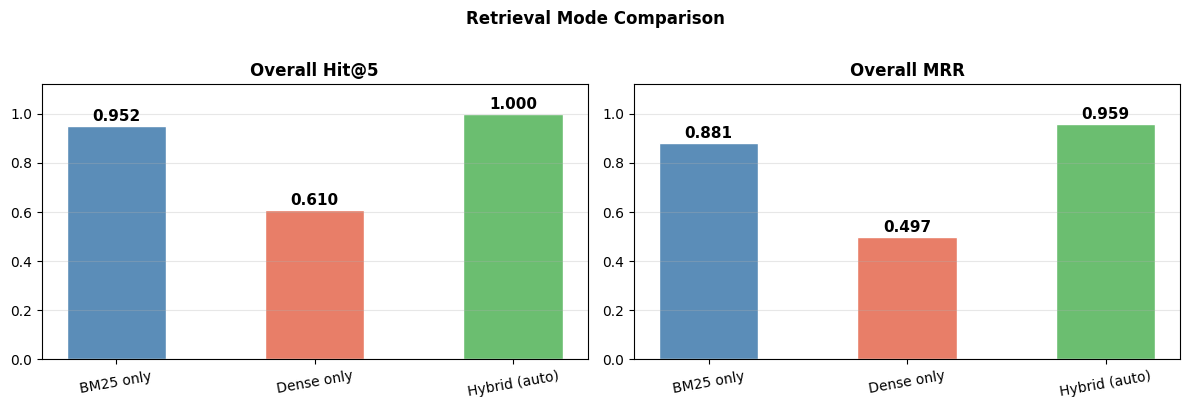

In [109]:
print("Evaluating three retrieval modes...")
df_auto  = evaluate(retriever, ground_truth, CONFIG, mode="auto")
df_bm25  = evaluate(retriever, ground_truth, CONFIG, mode="bm25")
df_dense = evaluate(retriever, ground_truth, CONFIG, mode="dense")

# Build a side-by-side comparison (OVERALL row only)
comparison = pd.DataFrame({
    "Mode":  ["BM25 only", "Dense only", "Hybrid (auto)"],
    "Hit@1": [df_bm25.iloc[-1]["Hit@1"], df_dense.iloc[-1]["Hit@1"], df_auto.iloc[-1]["Hit@1"]],
    "Hit@3": [df_bm25.iloc[-1]["Hit@3"], df_dense.iloc[-1]["Hit@3"], df_auto.iloc[-1]["Hit@3"]],
    "Hit@5": [df_bm25.iloc[-1]["Hit@5"], df_dense.iloc[-1]["Hit@5"], df_auto.iloc[-1]["Hit@5"]],
    "MRR":   [df_bm25.iloc[-1]["MRR"],   df_dense.iloc[-1]["MRR"],   df_auto.iloc[-1]["MRR"]],
})

print("\nOverall comparison:")
print(comparison.to_string(index=False))
print("\nPer-type breakdown (Hybrid/Auto mode):")
print(df_auto.to_string(index=False))

# Bar chart — one panel per metric
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors    = ["#5B8DB8", "#E87E68", "#6BBE70"]
for ax, metric in zip(axes, ["Hit@5", "MRR"]):
    vals = [float(comparison.loc[comparison["Mode"] == m, metric].values[0]) for m in comparison["Mode"]]
    bars = ax.bar(comparison["Mode"], vals, color=colors, width=0.5, edgecolor="white")
    ax.set_ylim(0, 1.12); ax.set_title(f"Overall {metric}", fontweight="bold")
    ax.yaxis.grid(True, alpha=0.3); ax.tick_params(axis="x", rotation=10)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                f"{b.get_height():.3f}", ha="center", fontsize=11, fontweight="bold")
plt.suptitle("Retrieval Mode Comparison", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

## 6 — Limitations & Roadmap

| # | Limitation | Example | Status | Fix |
|---|---|---|:---:|---|
| ① | **Unit variants** | `2cm`, `8cm`, `20.0m`, bare `20`, `millimetre` | 🔴 open | `MM_RE` only matches `mm`; extend to `cm` (×10), `m` (×1000), spelled-out `millimetre(s)`; infer unit from context for bare integers |
| ② | **Range queries** | `insulation 80mm to 120mm` | 🔴 open | Both endpoints parsed as two separate exact-match constraints by `OP_MM_RE.findall()`; no product stores both values simultaneously so re-rank falls back to raw BM25 with range intent lost; needs dedicated range operator |
| ③ | **Self-referential evaluation** | Synthetic ground truth built from the same parsed fields the retriever checks | 🟡 | MRR ≈ 1.0 on synthetic queries is expected, not surprising — it only shows the parser is internally consistent; the 17-query human-labelled set is the only honest signal; needs real user click-through logs or a larger expert-annotated set |


---

### Extending to richer LCA data

| New data field | New query type unlocked |
|---|---|
| GWP / ODP / AP (kg CO₂e per kg) | *"cement with GWP < 0.6 kg CO₂e/kg"* — carbon-threshold filter |
| Declared unit + application scenario | *"same application as product X but lower embodied carbon"* — substitution |
| Supplier region + stock availability | *"cheapest CEM I 42.5N in stock, EU supplier, min 500t"* — procurement |
